# Education Project

The purpose of this project is to answer the question is school performance associated with socioeconomic factors?

## Load and explore data

### Import libraries

In [1]:
# Import pandas, numpy, matplotlib, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set the plotting style
sns.set_style('whitegrid')

### Load the data

#### Load the EdGap date set

In [2]:
edgap = pd.read_excel(
    '/Users/mattejoey/Documents/MSDS-Fall-2026/DATA-5100/Projects/education/data/EdGap_data.xlsx',
    dtype={'NCESSCH School ID': object}
)

/opt/anaconda3/lib/python3.14/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


#### Load the school information data

In [3]:
school_information = pd.read_csv(
    '/Users/mattejoey/Documents/MSDS-Fall-2026/DATA-5100/Projects/education/data/ccd_sch_029_1617_w_1a_11212017.csv', encoding = 'unicode_escape'
)   

/var/folders/vh/0d9pw68j4132jv9wfznhv0km0000gn/T/ipykernel_44134/782027887.py:1: DtypeWarning: Columns (0: STATE_AGENCY_NO, 1: LEAID, 2: MSTREET2, 3: MSTREET3, 4: MZIP, 5: MZIP4, 6: LSTREET2, 7: LSTREET3, 8: LZIP, 9: LZIP4, 10: SY_STATUS, 11: UPDATED_STATUS, 12: SCH_TYPE, 13: CHARTAUTH1, 14: CHARTAUTH2, 15: CHARTAUTHN2) have mixed types. Specify dtype option on import or set low_memory=False.
  school_information = pd.read_csv(


### Explore the contents of the data sets

#### Start by looking at the head of each dataset

In [4]:
edgap.head()

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


In [5]:
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,...,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported


In [6]:
pd.set_option('display.max_columns', None)
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,MSTREET1,MSTREET2,MSTREET3,MCITY,MSTATE,MZIP,MZIP4,LSTREET1,LSTREET2,LSTREET3,LCITY,LSTATE,LZIP,LZIP4,PHONE,WEBSITE,SY_STATUS,SY_STATUS_TEXT,UPDATED_STATUS,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,RECON_STATUS,OUT_OF_STATE_FLAG,CHARTER_TEXT,CHARTAUTH1,CHARTAUTHN1,CHARTAUTH2,CHARTAUTHN2,NOGRADES,G_PK_OFFERED,G_KG_OFFERED,G_1_OFFERED,G_2_OFFERED,G_3_OFFERED,G_4_OFFERED,G_5_OFFERED,G_6_OFFERED,G_7_OFFERED,G_8_OFFERED,G_9_OFFERED,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0020,1.000020e+10,100277.0,P O Box 9486,NaN,NaN,Birmingham,AL,35220,NaN,1000 Industrial School Road,NaN,NaN,Birmingham,AL,35220,NaN,(205)680-8574,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0050,1.000020e+10,101667.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,1601 County Rd. 57,NaN,NaN,Prattville,AL,36067,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0060,1.000020e+10,101670.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,2109 Bashi Rd Bldg 509,NaN,NaN,Thomasville,AL,36784,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0030,1.000020e+10,101705.0,P O Box 66,NaN,NaN,Mount Meigs,AL,36057,NaN,1000 Industrial School Road,NaN,NaN,Mount Meigs,AL,36057,NaN,(334)215-6039,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0040,1.000020e+10,101706.0,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,(205)838-4981,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported


#### Use the `info` method to check data types, size, and numbers of missing values

In [7]:
edgap.info()

<class 'pandas.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


In [8]:
school_information.info()

<class 'pandas.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  str    
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  str    
 3   ST                   102183 non-null  str    
 4   SCH_NAME             102183 non-null  str    
 5   LEA_NAME             102183 non-null  str    
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  str    
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  str    
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  str    
 14  MSTREET2             1825 non-null    str    
 15  MSTREET3             28 non-

### Are the data suitable for answering the question?

Make a pair plot to explore the relationships between the variables

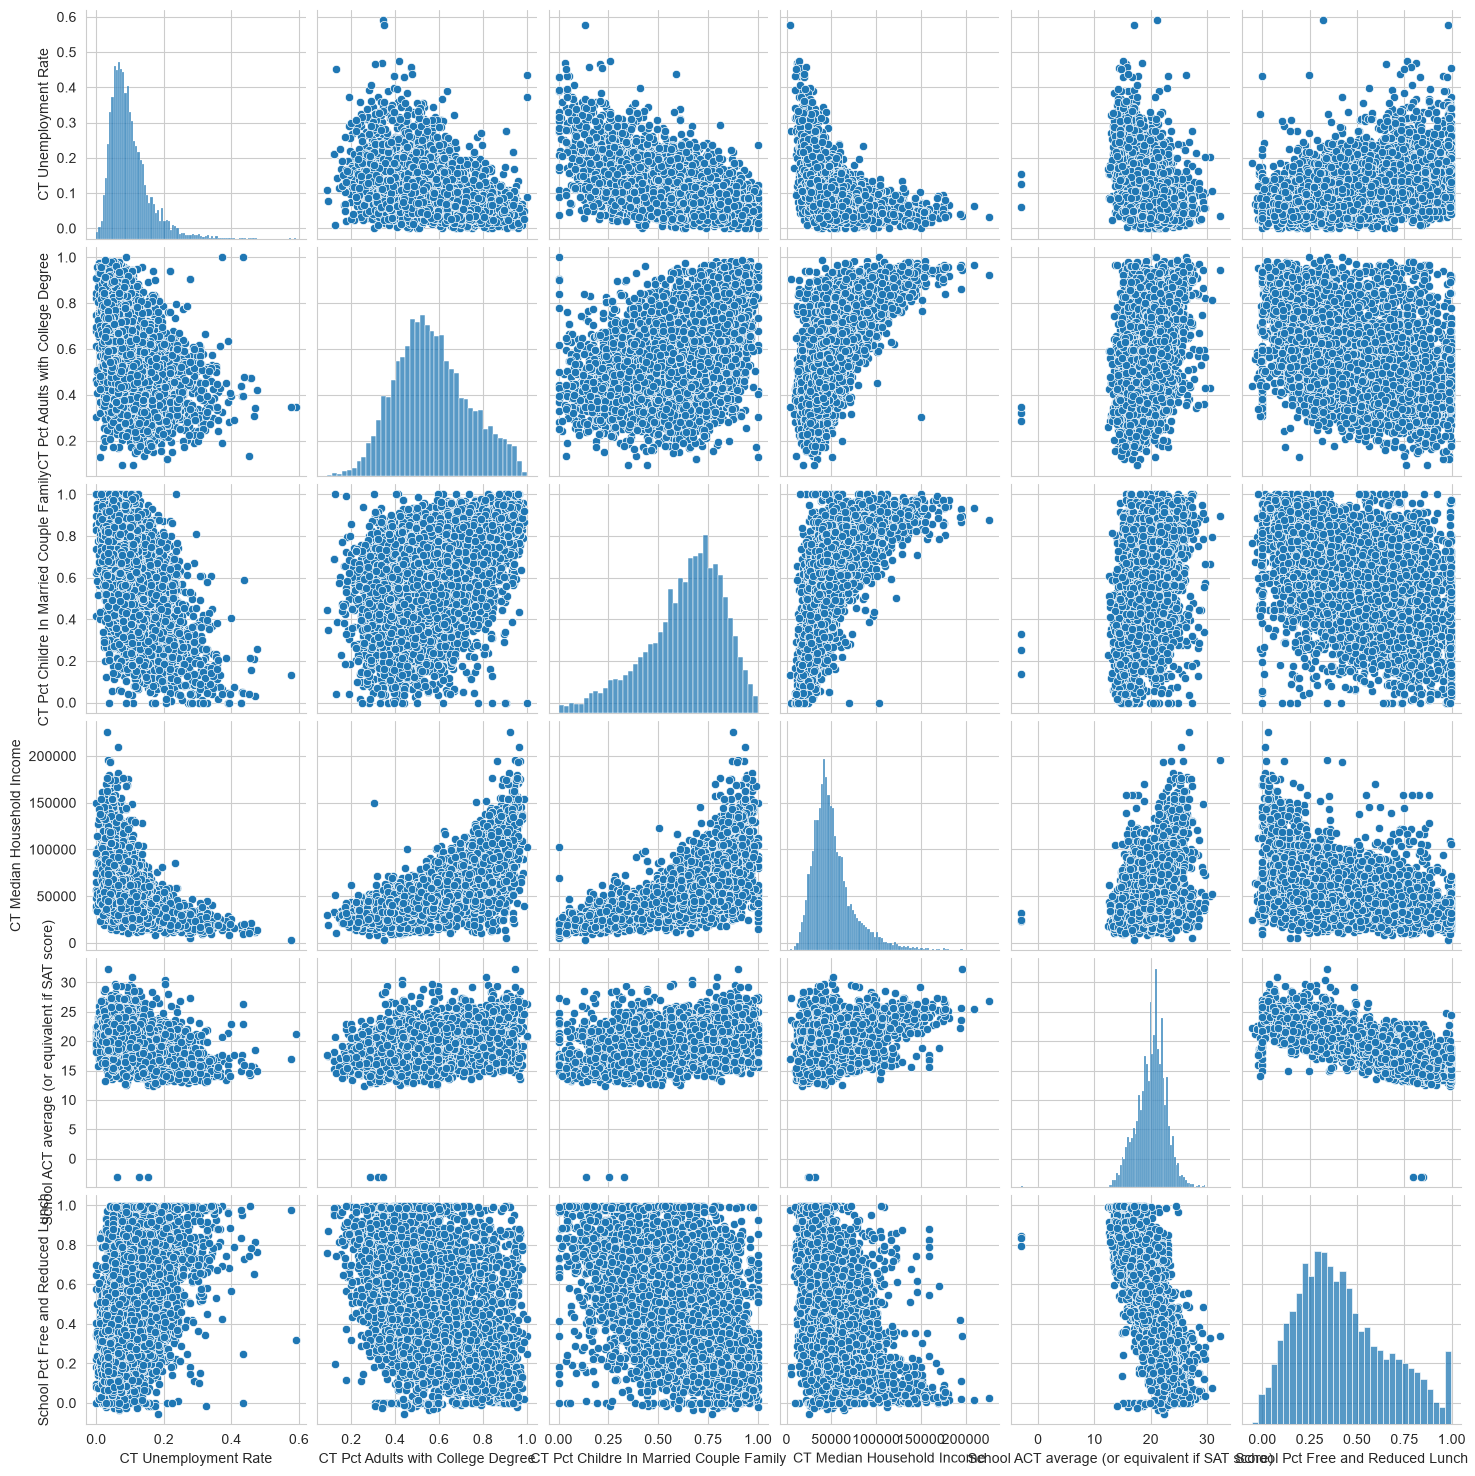

In [9]:
sns.pairplot(
    edgap.drop(columns='NCESSCH School ID')
);
plt.show()

Add regression lines and format the pair plot

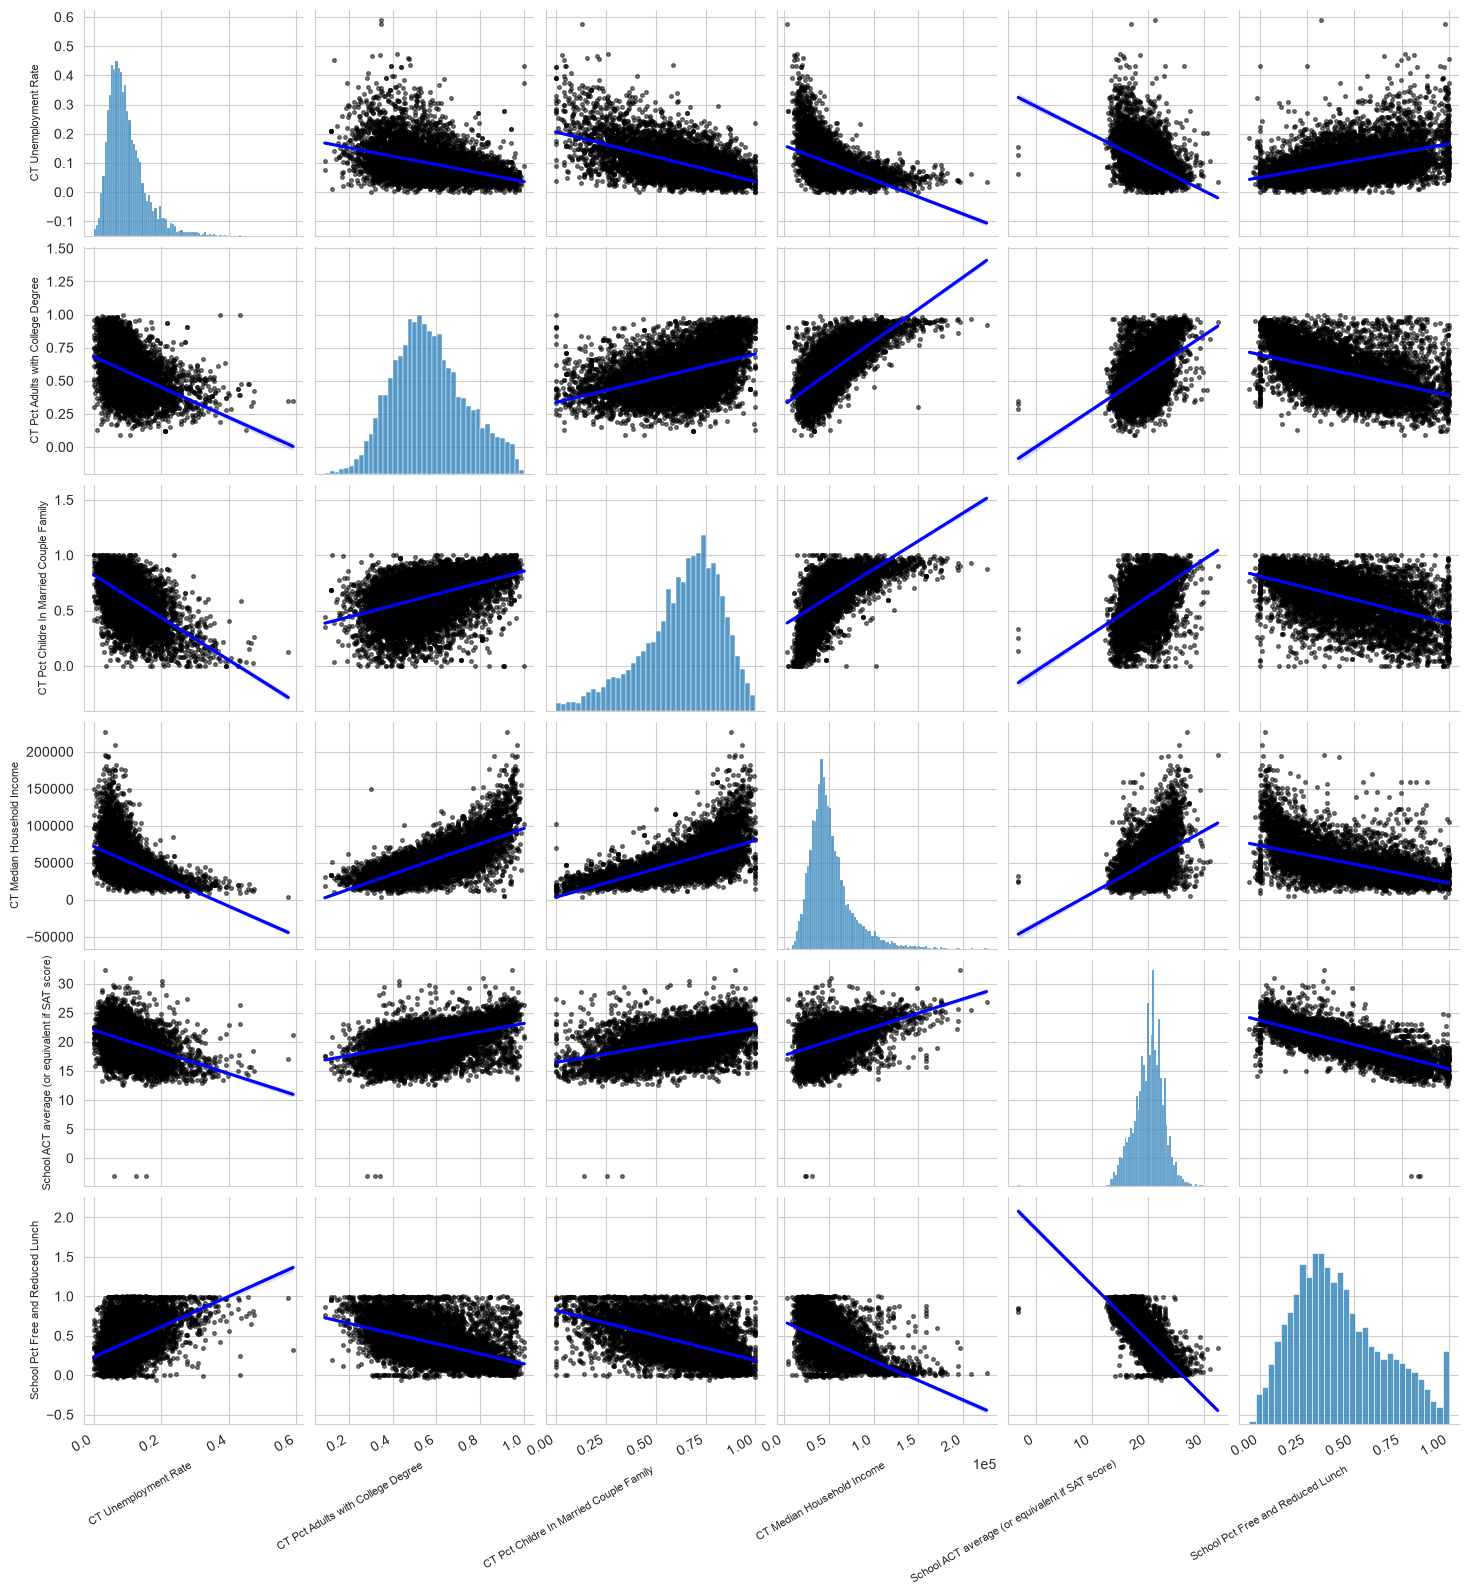

In [10]:
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID'),
    kind='reg',
    plot_kws={
        'line_kws': {'color': 'blue'},
        'scatter_kws': {'alpha': 0.5, 'color': 'k', 's': 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') #X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

Plot a single row

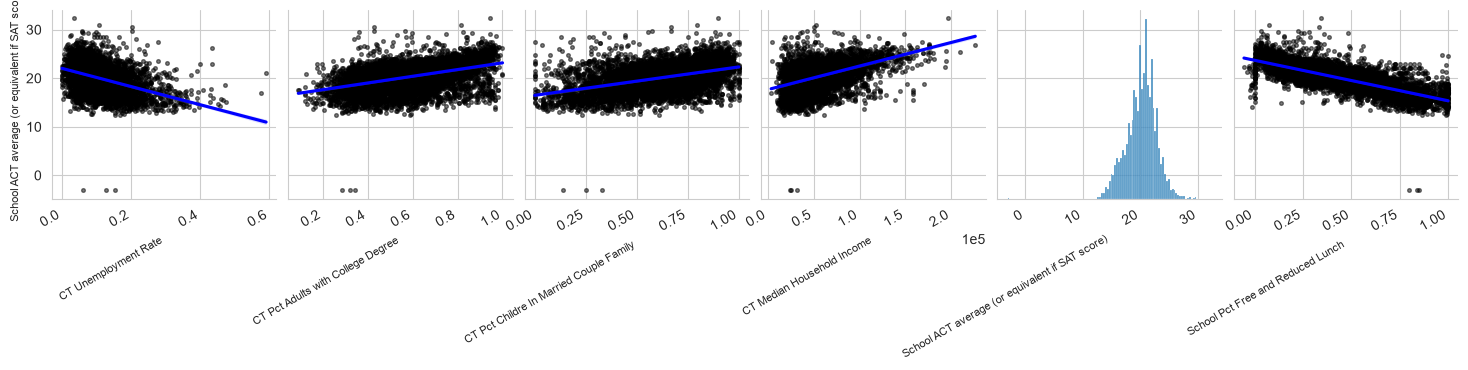

In [11]:
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID'),
    y_vars=['School ACT average (or equivalent if SAT score)'],
    kind='reg',
    plot_kws={
        'line_kws': {'color': 'blue'},
        'scatter_kws': {'alpha': 0.5, 'color': 'k', 's': 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') #X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

## Data Preparation

### Select relevant subsets of the data

We only need the year, school identity, location, and school type information of the school information data set. Keep columns SCHOOL_YEAR, NCESSCH, LSTATE, LZIP, SCH_TYPE_TEXT, LEVEL, CHARTER_TEXT

In [12]:
school_information = school_information[
    ['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT']
]

In [13]:
school_information.head()

,SCHOOL_YEAR,NCESSCH,LSTATE,LZIP,SCH_TYPE_TEXT,LEVEL,CHARTER_TEXT
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


### Rename columns

In [14]:
edgap = edgap.rename(
    columns={
        'NCESSCH School ID': 'id',
        'CT Pct Adults with College Degree': 'percent_college',
        'CT Unemployment Rate': 'rate_unemployment',
        'CT Pct Childre In Married Couple Family': 'percent_married',
        'CT Median Household Income': 'median_income',
        'School ACT average (or equivalent if SAT score)': 'average_act',
        'School Pct Free and Reduced Lunch': 'percent_lunch',
    }
)

In [15]:
school_information = school_information.rename(
    columns={
        'SCHOOL_YEAR': 'year',
        'NCESSCH': 'id',
        'LSTATE': 'state',
        'LZIP': 'zip_code',
        'SCH_TYPE_TEXT': 'school_type',
        'LEVEL': 'school_level',
        'CHARTER_TEXT': 'charter'
    }
)

In [16]:
edgap.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


In [17]:
school_information.head()

,year,id,state,zip_code,school_type,school_level,charter
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


## Join data frames

In [18]:
school_information['id'] = school_information['id'].astype('object')

In [19]:
school_information.info()

<class 'pandas.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          102183 non-null  str   
 1   id            102181 non-null  object
 2   state         102183 non-null  str   
 3   zip_code      102183 non-null  object
 4   school_type   102181 non-null  str   
 5   school_level  102179 non-null  str   
 6   charter       102179 non-null  str   
dtypes: object(2), str(5)
memory usage: 9.0+ MB


In [20]:
df = edgap.merge(
    school_information,
    how='left',
    on='id'
)

In [21]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7986 non-null   object 
 1   rate_unemployment  7972 non-null   float64
 2   percent_college    7973 non-null   float64
 3   percent_married    7961 non-null   float64
 4   median_income      7966 non-null   float64
 5   average_act        7986 non-null   float64
 6   percent_lunch      7986 non-null   float64
 7   year               7898 non-null   str    
 8   state              7898 non-null   str    
 9   zip_code           7898 non-null   object 
 10  school_type        7898 non-null   str    
 11  school_level       7898 non-null   str    
 12  charter            7898 non-null   str    
dtypes: float64(6), object(2), str(5)
memory usage: 1.0+ MB


## Quality Control

There are natural bounds for numerical values in the dataset. Check the minimum and maximum values for the columns.

In [23]:
df.describe()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729


In [24]:
df.select_dtypes(include=['number']).agg(['min', 'max']).round(2)

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
min,0.00,0.09,0.0,3589.0,-3.07,-0.05
max,0.59,1.00,1.0,226181.0,32.36,1.00


Set out of range values to NaN

In [25]:
df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan

In [26]:
df.loc[df['average_act'] < 1, 'average_act'] = np.nan

Check the types, levels, and charter status of schools

In [27]:
df['school_type'].value_counts()

school_type
Regular School                 7885
Alternative School               10
Special Education School          2
Career and Technical School       1
Name: count, dtype: int64

In [28]:
df['school_level'].value_counts()

school_level
High            7230
Other            631
Not reported      35
Elementary         2
Name: count, dtype: int64

In [29]:
df['charter'].value_counts()

charter
No                7329
Yes                352
Not applicable     217
Name: count, dtype: int64

Keep only the high schools

In [30]:
df = df.loc[df['school_level'] == 'High']

Check for any duplicated rows

In [31]:
df.duplicated().sum()

np.int64(0)

### Identify missing values

How many values are missing for each variable?

In [32]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,3
percent_lunch,20
year,0
state,0
zip_code,0


What percentage of values of each variable are missing?

In [33]:
percent_missing = df.isna().mean().round(4) * 100
percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.17
percent_college,0.15
percent_married,0.28
median_income,0.22
average_act,0.04
percent_lunch,0.28
year,0.00
state,0.00
zip_code,0.00


What states do we have data from?

In [34]:
df['state'].value_counts()

state
TX    913
OH    654
IL    564
PA    543
MI    498
NC    407
FL    404
GA    367
WI    351
NJ    341
MO    337
IN    321
NY    295
TN    265
WA    263
MA    253
KY    198
LA    194
WY     38
DE     24
Name: count, dtype: int64

In [35]:
df['state'].nunique()

20

Plot the results on a map

In [36]:
import plotly.offline as po
import plotly.graph_objs as pg

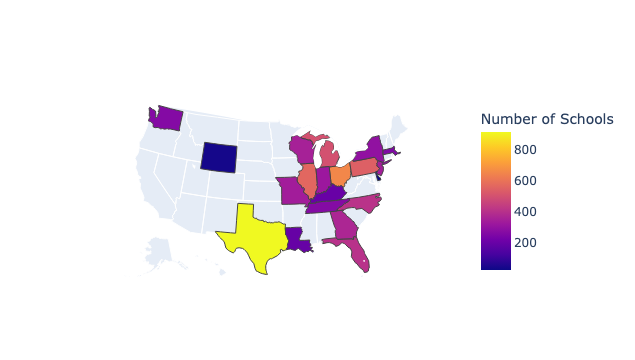

In [37]:
layout = dict(
    geo={'scope': 'usa'}, coloraxis_colorbar=dict(title='Number of Schools')
)

data = dict(
    type='choropleth',
    locations=df['state'].value_counts().index,
    locationmode='USA-states',
    z=df['state'].value_counts().values,
    coloraxis='coloraxis',
)

x = pg.Figure(data=[data], layout=layout)

po.iplot(x)

Drop the rows where the average ACT score is missing

In [38]:
df = df.dropna(subset=['average_act'])

In [39]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,0
percent_lunch,20
year,0
state,0
zip_code,0


We will impute the missing values for the other columns

## Data Imputation

In [40]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]

Use an iterative imputer to replace missing values

In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [42]:
imputer = IterativeImputer()

Fit the imputer using the numerical predictor values

In [43]:
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


In [44]:
imputer.fit(df.loc[:, numerical_predictors])

,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",None
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False
,"max_iter max_iter: int, default=10Maximum number of imputation rounds to perform before returning theimputations computed during the final round. A round is a singleimputation of each feature with missing values. The stopping criterionis met once `max(abs(X_t - X_{t-1}))/max(abs(X[known_vals])) < tol`,where `X_t` is `X` at iteration `t`. Note that early stopping is onlyapplied if `sample_posterior=False`.",10
,"tol tol: float, default=1e-3Tolerance of the stopping condition.",0.001
,"n_nearest_features n_nearest_features: int, default=NoneNumber of other features to use to estimate the missing values ofeach feature column. Nearness between features is measured usingthe absolute correlation coefficient between each feature pair (afterinitial imputation). To ensure coverage of features throughout theimputation process, the neighbor features are not necessarily nearest,but are drawn with probability proportional to correlation for eachimputed target feature. Can provide significant speed-up when thenumber of features is huge. If `None`, all features will be used.",None
,"initial_strategy initial_strategy: {'mean', 'median', 'most_frequent', 'constant'}, default='mean'Which strategy to use to initialize the missing values. Same as the`strategy` parameter in :class:`~sklearn.impute.SimpleImputer`.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen `strategy=""constant""`, `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types... versionadded:: 1.3",None
,"imputation_order imputation_order: {'ascending', 'descending', 'roman', 'arabic', 'random'}, default='ascending'The order in which the features will be imputed. Possible values:- `'ascending'`: From features with fewest missing values to most.- `'descending'`: From features with most missing values to fewest.- `'roman'`: Left to right.- `'arabic'`: Right to left.- `'random'`: A random order for each round.",'ascending'
,"skip_complete skip_complete: bool, default=FalseIf `True` then features with missing values during :meth:`transform`which did not have any missing values during :meth:`fit` will beimputed with the initial imputation method only. Set to `True` if youhave many features with no missing values at both :meth:`fit` and:meth:`transform` time to save compute.",False
,"min_value min_value: float or array-like of shape (n_features,), default=-np.infMinimum possible imputed value. Broadcast to shape `(n_features,)` ifscalar. If array-like, expects shape `(n_features,)`, one min value foreach feature. The default is `-np.inf`... versionchanged:: 0.23 Added support for array-like.",-inf


Impute the missing values in the training data

In [45]:
df.loc[:,numerical_predictors] = imputer.transform(df.loc[:, numerical_predictors])

Check for missing values

In [46]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
year,0
state,0
zip_code,0


### Export the clean data set

In [47]:
df.to_csv(
    'education_clean.csv',
    encoding='utf-8-sig',
    index=False
)